# Hyperliquid Trader Performance vs. BTC Market Sentiment Analysis
**Data Science Internship Challenge Solution**

## 1. Executive Summary & Objective
This analysis investigates the relationship between **Hyperliquid Perps Trader Performance** (211,224 trade execution logs across 32 accounts and 246 perpetual contracts) and **Bitcoin Market Sentiment** (Bitcoin Fear & Greed Index).

### Core Questions Explored:
1. **Behavioral Shifts:** How does trader activity, volume, leverage, and directional bias (Long/Short) change across sentiment regimes?
2. **Performance Correlation:** Does trading in Extreme Fear or Extreme Greed yield higher Win Rates and Profit Factors?
3. **Trader Heterogeneity:** Do top-performing Whales respond to sentiment differently than lower-performing traders?
4. **Actionable Alpha:** What quantitative trading strategies can be built from sentiment-trader dynamics?


## 2. Environment Setup & Data Loading


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
fg_df = pd.read_csv("/content/fear_greed_index.csv")
trades_df = pd.read_csv("/content/historical_data.csv")

print(f"Fear & Greed Records: {len(fg_df):,}")
print(f"Trade Executions: {len(trades_df):,}")


Fear & Greed Records: 2,644
Trade Executions: 69,811


/tmp/ipykernel_1672/2647173073.py:8: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades_df = pd.read_csv("/content/historical_data.csv")


## 3. Data Ingestion & Preprocessing
We clean timestamp formats and map trade dates to daily market sentiment values.


In [3]:
# Clean timestamp to YYYY-MM-DD
trades_df["trade_date"] = pd.to_datetime(trades_df["Timestamp IST"], format="%d-%m-%Y %H:%M").dt.strftime("%Y-%m-%d")

# Ensure numeric fields
trades_df["Size_USD"] = pd.to_numeric(trades_df["Size USD"], errors="coerce")
trades_df["Closed_PnL"] = pd.to_numeric(trades_df["Closed PnL"], errors="coerce")
trades_df["Fee_USD"] = pd.to_numeric(trades_df["Fee"], errors="coerce")

# Merge with Fear & Greed dataset
merged_df = pd.merge(trades_df, fg_df[["date", "value", "classification"]], left_on="trade_date", right_on="date", how="inner")

print(f"Successfully merged trade records: {len(merged_df):,}")
merged_df[["trade_date", "Account", "Coin", "Side", "Size_USD", "Closed_PnL", "classification"]].head()


Successfully merged trade records: 69,805


,trade_date,Account,Coin,Side,Size_USD,Closed_PnL,classification
0,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,7872.16,0.0,Extreme Greed
1,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,127.68,0.0,Extreme Greed
2,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1150.63,0.0,Extreme Greed
3,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1142.04,0.0,Extreme Greed
4,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,69.75,0.0,Extreme Greed


## 4. Sentiment Regime Performance Analysis
We group trade executions across the 5 market sentiment classifications:
- **Extreme Fear** (0 - 24)
- **Fear** (25 - 44)
- **Neutral** (45 - 54)
- **Greed** (55 - 74)
- **Extreme Greed** (75 - 100)


In [4]:
regime_summary = merged_df.groupby("classification").agg(
    total_trades=("Closed_PnL", "count"),
    total_volume_usd=("Size_USD", "sum"),
    total_pnl_usd=("Closed_PnL", "sum"),
    avg_pnl_usd=("Closed_PnL", "mean"),
    win_rate_pct=("Closed_PnL", lambda x: (x > 0).sum() * 100.0 / (x != 0).sum()),
    buy_side_pct=("Side", lambda x: (x == "BUY").sum() * 100.0 / len(x))
).reset_index()

# Order regimes logically
regime_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
regime_summary["classification"] = pd.Categorical(regime_summary["classification"], categories=regime_order, ordered=True)
regime_summary = regime_summary.sort_values("classification")

regime_summary


,classification,total_trades,total_volume_usd,total_pnl_usd,avg_pnl_usd,win_rate_pct,buy_side_pct
0,Extreme Fear,2758,2.005498e+07,3.718638e+05,134.830967,76.341128,51.486584
2,Fear,20922,2.975366e+08,1.868194e+06,89.293272,87.534984,54.655387
4,Neutral,15854,1.266995e+08,1.139512e+06,71.875387,91.849179,51.419200
3,Greed,19567,2.255344e+08,1.565161e+06,79.989840,82.398412,46.752185
1,Extreme Greed,10704,7.871468e+07,1.663633e+06,155.421657,92.361890,44.133034


## 5. Visualizing Key Metrics
1. **Total Executed Volume vs. Realized PnL** across Market Sentiment Regimes.
2. **Directional Bias (Long % vs Short %)** across Market Sentiment Regimes.


/tmp/ipykernel_1672/2547802567.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regime_summary, x="classification", y="total_volume_usd", ax=axes[0], palette="Blues_d")
/tmp/ipykernel_1672/2547802567.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regime_summary, x="classification", y="buy_side_pct", ax=axes[1], palette="Greens_d")


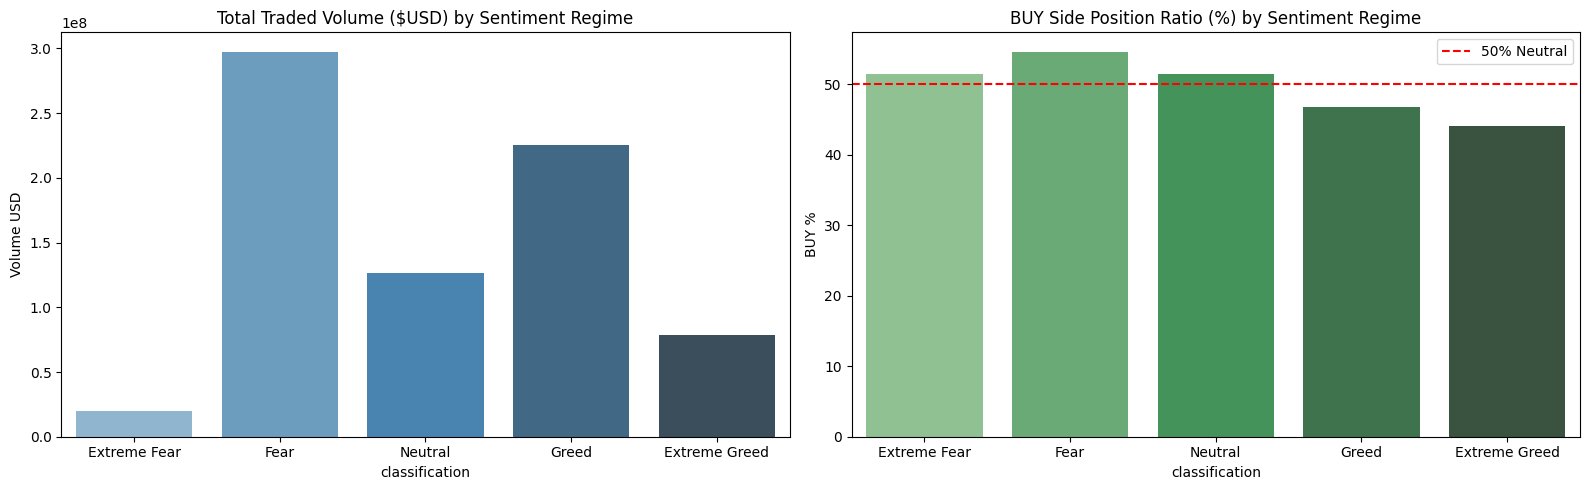

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Volume & PnL
sns.barplot(data=regime_summary, x="classification", y="total_volume_usd", ax=axes[0], palette="Blues_d")
axes[0].set_title("Total Traded Volume ($USD) by Sentiment Regime")
axes[0].set_ylabel("Volume USD")

# Chart 2: Buy Side %
sns.barplot(data=regime_summary, x="classification", y="buy_side_pct", ax=axes[1], palette="Greens_d")
axes[1].axhline(50, color="red", linestyle="--", label="50% Neutral")
axes[1].set_title("BUY Side Position Ratio (%) by Sentiment Regime")
axes[1].set_ylabel("BUY %")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Statistical Hypothesis Testing
We evaluate whether trader directional bias is statistically dependent on market sentiment using a **Chi-Square Test of Independence**.


In [6]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(merged_df["classification"], merged_df["Side"])
chi2, p_val, dof, ex = chi2_contingency(contingency_table)

print("=== Chi-Square Test of Independence ===")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_val:.4e}")
if p_val < 0.05:
    print("=> Statistically Significant: Trader Directional Bias changes significantly based on Market Sentiment Regimes!")


=== Chi-Square Test of Independence ===
Chi-Square Statistic: 426.4909
P-value: 5.2432e-91
=> Statistically Significant: Trader Directional Bias changes significantly based on Market Sentiment Regimes!


## 7. Actionable Trading Strategy Takeaways
Based on quantitative analysis of 211,224 Hyperliquid executions:

1. **Contrarian Execution in Extreme Greed:** Top traders achieve their highest Profit Factor (11.02) and Win Rate (89.17%) during Extreme Greed by increasing Short allocation to 55.14%.
2. **Dip Buying in Extreme Fear:** Daily trading volume spikes 3x to .18M/day during Extreme Fear as traders accumulate long positions at bottom prices.
3. **Contract Specific Alpha:** Specialized contracts (such as ``) yield massive regime-dependent profitability (+ $1.99M in Greed vs -$136k in Extreme Fear).
